# PART-I

In [1]:
import tensorflow as tf
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
import itertools

from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau
from keras.models import Sequential, Model
from keras.layers import Dense, Activation, Flatten, Dropout, concatenate, Input, Conv2D, MaxPooling2D
from keras.optimizers import Adam, Adadelta
from keras.layers.advanced_activations import LeakyReLU
from keras.utils.np_utils import to_categorical

In [2]:
train_dir = '../http://localhost:8891/tree/CNN_Part1/train'
prediction_dir = '../http://localhost:8891/tree/CNN_Part1/prediction'

In [3]:
# Define Y-labels and NUM_CLASSES
SPECIES = ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen',
              'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'Shepherds Purse',
              'Small-flowered Cranesbill', 'Sugar beet']
NUM_SPECIES = len(SPECIES)

In [4]:

for species in SPECIES:
    print('{} {} images'.format(species, len(SPECIES)))
  

Black-grass 12 images
Charlock 12 images
Cleavers 12 images
Common Chickweed 12 images
Common wheat 12 images
Fat Hen 12 images
Loose Silky-bent 12 images
Maize 12 images
Scentless Mayweed 12 images
Shepherds Purse 12 images
Small-flowered Cranesbill 12 images
Sugar beet 12 images


In [5]:
image_size = 256
batch_size = 32

In [6]:
idg = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    #rotation_range=20,
    #width_shift_range=0.2,
    #height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2)

In [7]:
train_gen = idg.flow_from_directory('../CNN_Part1/train',
                                                    target_size=(image_size, image_size),
                                                    subset='training',
                                                    class_mode='categorical',
                                                    batch_size=batch_size,
                                                    shuffle=True,
                                                    seed=1  )

Found 3816 images belonging to 12 classes.


In [8]:
val_gen = idg.flow_from_directory('../CNN_Part1/train/',
                                                   target_size=(image_size, image_size),                                                   
                                                   subset='validation',
                                                   class_mode='categorical',
                                                   batch_size=batch_size,
                                                   shuffle=True,
                                                   seed=1
                                                )

Found 951 images belonging to 12 classes.


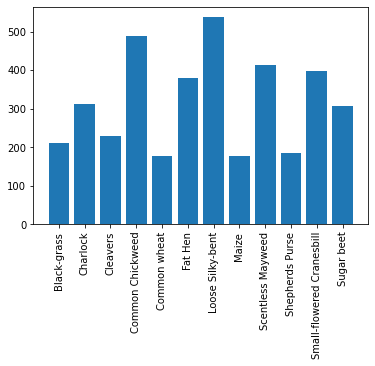

In [9]:
unique, counts = np.unique(train_gen.classes, return_counts=True)
dict1 = dict(zip(train_gen.class_indices, counts))

keys = dict1.keys()
values = dict1.values()

plt.xticks(rotation='vertical')
bar = plt.bar(keys, values)

In [10]:
x,y = next(train_gen)

In [11]:
from mpl_toolkits.axes_grid1 import ImageGrid

def show_grid(image_list, nrows, ncols, label_list=None, show_labels=False, figsize=(10,10)):

    fig = plt.figure(None, figsize,frameon=False)
    grid = ImageGrid(fig, 111, 
                     nrows_ncols=(nrows, ncols),  
                     axes_pad=0.2, 
                     share_all=True,
                     )
    for i in range(nrows*ncols):
        ax = grid[i]
        ax.imshow(image_list[i],cmap='Greys_r')
        ax.axis('off')

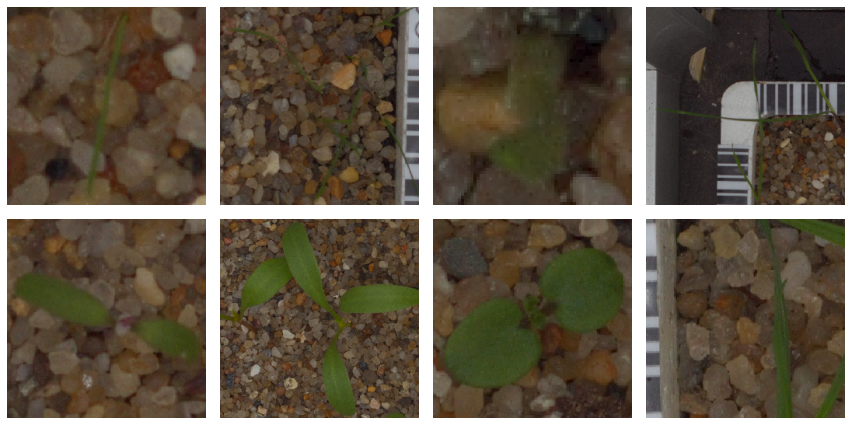

In [12]:
show_grid(x,2,4,show_labels=True,figsize=(15,15))

In [13]:
#build the model

#Clear any previous model from memory
tf.keras.backend.clear_session()

#Initialize model
model = tf.keras.models.Sequential()

#Add 1st Conv Layer
model.add(tf.keras.layers.Conv2D(64, kernel_size=(3, 3), input_shape=(256, 256, 3), activation='relu'))

#Add 2nd Conv Layer
model.add(tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))

#normalize data
model.add(tf.keras.layers.BatchNormalization())

#Add Max Pool layer
model.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))

#Add 3rd Conv Layer
model.add(tf.keras.layers.Conv2D(128, kernel_size=(3,3), activation='relu'))

#normalize data
model.add(tf.keras.layers.BatchNormalization())

#Add Max Pool layer
model.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))

#Add 4th Conv Layer
model.add(tf.keras.layers.Conv2D(256, kernel_size=(3,3), activation='relu'))

#normalize data
model.add(tf.keras.layers.BatchNormalization())

#Add Max Pool layer
model.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))

#Add Global Max Pool layer
model.add(tf.keras.layers.GlobalMaxPool2D())

#Flatten the data
model.add(tf.keras.layers.Flatten())

#Add 1st dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))

#normalize data
model.add(tf.keras.layers.BatchNormalization())

#Add Dropout
model.add(tf.keras.layers.Dropout(0.3))

#Add 2nd dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))

#normalize data
model.add(tf.keras.layers.BatchNormalization())

#Add Dropout
model.add(tf.keras.layers.Dropout(0.3))

#Add Output Layer
model.add(tf.keras.layers.Dense(12, activation='softmax'))

In [14]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [15]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 254, 254, 64)      1792      
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 252, 252, 64)      36928     
_________________________________________________________________
batch_normalization (BatchNo (None, 252, 252, 64)      256       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 126, 126, 64)      0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 124, 124, 128)     73856     
_________________________________________________________________
batch_normalization_1 (Batch (None, 124, 124, 128)     512       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 62, 62, 128)       0

In [16]:
checkpoint = tf.keras.callbacks.ModelCheckpoint('plant_classifier.h5', #where to save the model
                                                    save_best_only=True, 
                                                    monitor='val_accuracy', 
                                                    mode='max', 
                                                    verbose = 1)

In [ ]:
#my system takes more time for this operation, thatswhy i use only 5 epochs
history = model.fit(train_gen,
          epochs=5,
          steps_per_epoch= 3816//batch_size,  # Number of train images // batch_size
          validation_data=val_gen,
          validation_steps = 951//batch_size, # Number of val images // batch_size
          callbacks = [checkpoint],
          verbose = 1)

Epoch 1/5
  7/119 [>.............................] - ETA: 3:12:18 - loss: 3.3239 - accuracy: 0.1473- ETA: 2:15:53 - loss: 3.5624 - accuracy: 0.135 - ETA: 2:54:24 - loss: 3.5780 - accuracy: 0.132 - ETA: 3:12:41 - loss: 3.4242 - accuracy: 0.13

In [ ]:
import pickle 
  
def storeData(): 
    # initializing data to be stored in db 
    chandana = {'key' : 'chandana', 'name' : 'chandana urang', 
    'age' : 27, 'pay' : 20000} 
    Great = {'key' : 'Great', 'name' : 'Great learning', 
    'age' : 50, 'pay' : 20000} 
  
    # database 
    db = {} 
    db['chandana'] = chandana 
    db['Great'] = Great 
      
    # Its important to use binary mode 
    dbfile = open('plantclassifierPickle', 'ab') 
      
    # source, destination 
    pickle.dump(db, dbfile)                      
    dbfile.close() 
  
def loadData(): 
    # for reading also binary mode is important 
    dbfile = open('plantclassifierPickle', 'rb')      
    db = pickle.load(dbfile) 
    for keys in db: 
        print(keys, '=>', db[keys]) 
    dbfile.close() 
  
if __name__ == '__main__': 
    storeData() 
    loadData() 

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(list(range(1,21)))
plt.ylim([0, 1])
plt.legend(loc='lower right')

In [ ]:
#visualization

maize = cv2.imread('../CNN_Part1/train/Maize/dc7a7bdeb.png')
plt.imshow(maize)

In [ ]:
#predicting input image using trained model
from keras.models import load_model
from keras.preprocessing import image

# dimensions of our images
img_width, img_height = 320, 240

# load the model we saved
model = load_model('plant_classifier.h5')
model.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

# predicting images
img = image.load_img('Predict (1).png', target_size=(img_width, img_height))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

images = np.vstack([x])
classes = model.predict_classes(images, batch_size=10)
print classes

# part-III

In [38]:
import skimage.io as io
import matplotlib.pyplot as plt
import numpy as np

# Read the image
img = io.imread('00002.jpg')

plt.imshow(img)
plt.show()

ModuleNotFoundError: No module named 'skimage'

In [ ]:
img.shape

In [ ]:
# Split
red = img[:, :, 0]
green = img[:, :, 1]
blue = img[:, :, 2]

In [ ]:
plt.imshow(red, cmap="Reds")
plt.show()

In [ ]:
plt.imshow(green, cmap="Greens")
plt.show()

In [ ]:
plt.imshow(blue, cmap="Blues")
plt.show()

In [ ]:
def filtering(img, f=3):
    
    # Dimensions from the input shape
    (rows, col, channels) = img.shape
    
    # Initialize "hyper parameters"
    stride = 2
    
    # Dimensions of the output
    n_rows = int(1 + (rows - f) / stride)
    n_col = int(1 + (col - f) / stride)
    n_channels = channels
    
    # Initialize output matrix A
    n_img = np.zeros((n_rows, n_col, n_channels))              
    
    # iterate through img
    for h in range(n_rows):                     
        for w in range(n_col):                 
            for c in range (n_channels):            
                vert_start = h*stride
                vert_end = vert_start + f
                horiz_start = w*stride
                horiz_end = horiz_start + f

                # extract slice we are dealing with
                n_slice = img[vert_start:vert_end, horiz_start:horiz_end, c]

                # Compute the filtering operation on the slice
                n_img[h, w, c] = np.mean(n_slice, dtype=int)
    return n_img

# PART-IV

In [1]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
import matplotlib.pyplot as plt

import cv2

In [3]:
import keras
from keras.layers import Dense,Conv2D,Dropout,BatchNormalization,Activation,Flatten,MaxPool2D,Input,LeakyReLU
from keras.models import Sequential
from keras.activations import relu
from keras.optimizers import Adam,RMSprop,SGD
from keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.applications.vgg16 import VGG16
from sklearn import svm
from keras.preprocessing import image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import os
import cv2
from sklearn.model_selection import train_test_split
import sklearn.preprocessing as pr

In [34]:
# Set the path of the input folder 

data = "../Downloads/flower/17flowers- train/jpg"

# List out the directories inside the main input folder

folders = os.listdir(data)

print(folders)

['.DS_Store', '0', '1', '10', '11', '12', '13', '14', '15', '16', '2', '3', '4', '5', '6', '7', '8', '9', 'files.txt', 'files.txt~', 'image_0001.jpg', 'image_0002.jpg', 'image_0003.jpg', 'image_0004.jpg', 'image_0005.jpg', 'image_0006.jpg', 'image_0007.jpg', 'image_0008.jpg', 'image_0009.jpg', 'image_0010.jpg', 'image_0011.jpg', 'image_0012.jpg', 'image_0013.jpg', 'image_0014.jpg', 'image_0015.jpg', 'image_0016.jpg', 'image_0017.jpg', 'image_0018.jpg', 'image_0019.jpg', 'image_0020.jpg', 'image_0021.jpg', 'image_0022.jpg', 'image_0023.jpg', 'image_0024.jpg', 'image_0025.jpg', 'image_0026.jpg', 'image_0027.jpg', 'image_0028.jpg', 'image_0029.jpg', 'image_0030.jpg', 'image_0031.jpg', 'image_0032.jpg', 'image_0033.jpg', 'image_0034.jpg', 'image_0035.jpg', 'image_0036.jpg', 'image_0037.jpg', 'image_0038.jpg', 'image_0039.jpg', 'image_0040.jpg', 'image_0041.jpg', 'image_0042.jpg', 'image_0043.jpg', 'image_0044.jpg', 'image_0045.jpg', 'image_0046.jpg', 'image_0047.jpg', 'image_0048.jpg', 'im

In [71]:
# Import the images and resize them to 64/64size
# Also generate the corresponding labels

image_names = []
train_labels = []
train_images = []

size = 64,64

for folder in folders:
    for file in os.listdir(os.path.join(data,folder)):
        
        if file.endswith('jpg'):
            image_names.append(os.path.join(data,folder,file))
            train_labels.append(folder)
            img = cv2.imread(os.path.join(data,folder,file))
            im = cv2.resize(img,size)
            train_images.append(im)
        else:
            continue

NotADirectoryError: [WinError 267] The directory name is invalid: '../Downloads/flower/17flowers- train/jpg\\.DS_Store'

i am facing problem with directory, can't resize them.

In [ ]:
# Transform the image array to a numpy type

train = np.array(train_images)

train.shape

In [ ]:
# Reduce the RGB values between 0 and 1

train = train.astype('float32') / 255.0

In [ ]:
# Extract the labels

label_dummies = pandas.get_dummies(train_labels)

labels =  label_dummies.values.argmax(1

In [ ]:
pd.unique(train_labels)

In [ ]:
# Shuffle the labels and images randomly for better results

union_list = list(zip(train, labels))
random.shuffle(union_list)
train,labels = zip(*union_list)

# Convert the shuffled list to numpy array type

train = np.array(train)
labels = np.array(labels)

In [ ]:
# Develop a sequential model using tensorflow keras

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(64,64,3)),
    keras.layers.Dense(128, activation=tf.nn.tanh),
    keras.layers.Dense(5, activation=tf.nn.softmax)])

In [ ]:
# Compute the model parameters

model.compile(optimizer=tf.train.AdamOptimizer(), 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train the model  with 5 epochs 

model.fit(train,labels, epochs=5)

# part-II

TASK: Explain  in  depth  why  CNN  out  performs  neural  networks  which  in  turn  out  perform  supervised  learning models when it comes to image classification. Use the markdown option in Jupiter for your answer.


Ans= Neural Networks are basically a default name given to a huge class of ML algorithms rather called a framework where the input data is sent to each neuron of the first layer, each neuron then does a dot product of the input data with the weight of the neuron and consequently the results are then feed forwarded to the neurons of the next layer and the process goes on until an output if generated.

But in case of convolution neural network (CNN) small matrices are assigned for the weight which is then convolved with each of the pixels to produce a new pixel. This new image produced is then feed forwarded to the next layers of the network until the end is reached. This is the reason why CNN is heavily used in image classification and stuff whereas regular neural networks are used in complex numerical data.

CNNs can be thought of automatic feature extractors from the image. While if  using a algorithm with pixel vector it loses a lot of spatial interaction between pixels, a CNN effectively uses adjacent pixel information to effectively downsample the image first by convolution and then uses a prediction layer at the end.

#Due to Epoch processing my system hang as many time i tried, may be my system is in a problem.
This time i couldnot able to solve this problem. Later i will solve this and re-submit my submission. 
